# Phase 8 — Notebook 9: The Hugging Face Ecosystem

> **Phase Continuity**: Notebooks 4–8 showed us how BERT and GPT work conceptually and architecturally. This final practical notebook covers the Hugging Face tools that make these models accessible in just a few lines of code — and shows how to use them effectively for real NLP tasks.

---

In [1]:
# Install core Hugging Face libraries
import subprocess, sys
for pkg in ['transformers', 'datasets', 'evaluate', 'accelerate', 'sentencepiece']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '--quiet'], check=True)
print('All Hugging Face libraries installed.')

All Hugging Face libraries installed.


## 1. The Hugging Face Hub — The NLP App Store

The [Hugging Face Hub](https://huggingface.co) is the central repository for the open-source ML community:

| Resource | Count (2024) | Description |
|---|---|---|
| **Models** | 500,000+ | Pre-trained models for every task and modality |
| **Datasets** | 100,000+ | Benchmarks, labeled corpora, raw text collections |
| **Spaces** | 300,000+ | Hosted demo apps (Gradio / Streamlit) |

### Model Cards
Every model on the Hub comes with a **Model Card** — standardized documentation covering:
- What the model was trained on and its intended use
- Known biases, limitations, and risks
- Evaluation results across benchmarks
- Carbon footprint of training

This is a form of **responsible AI documentation** that makes it easier to choose the right model for your use case.

---

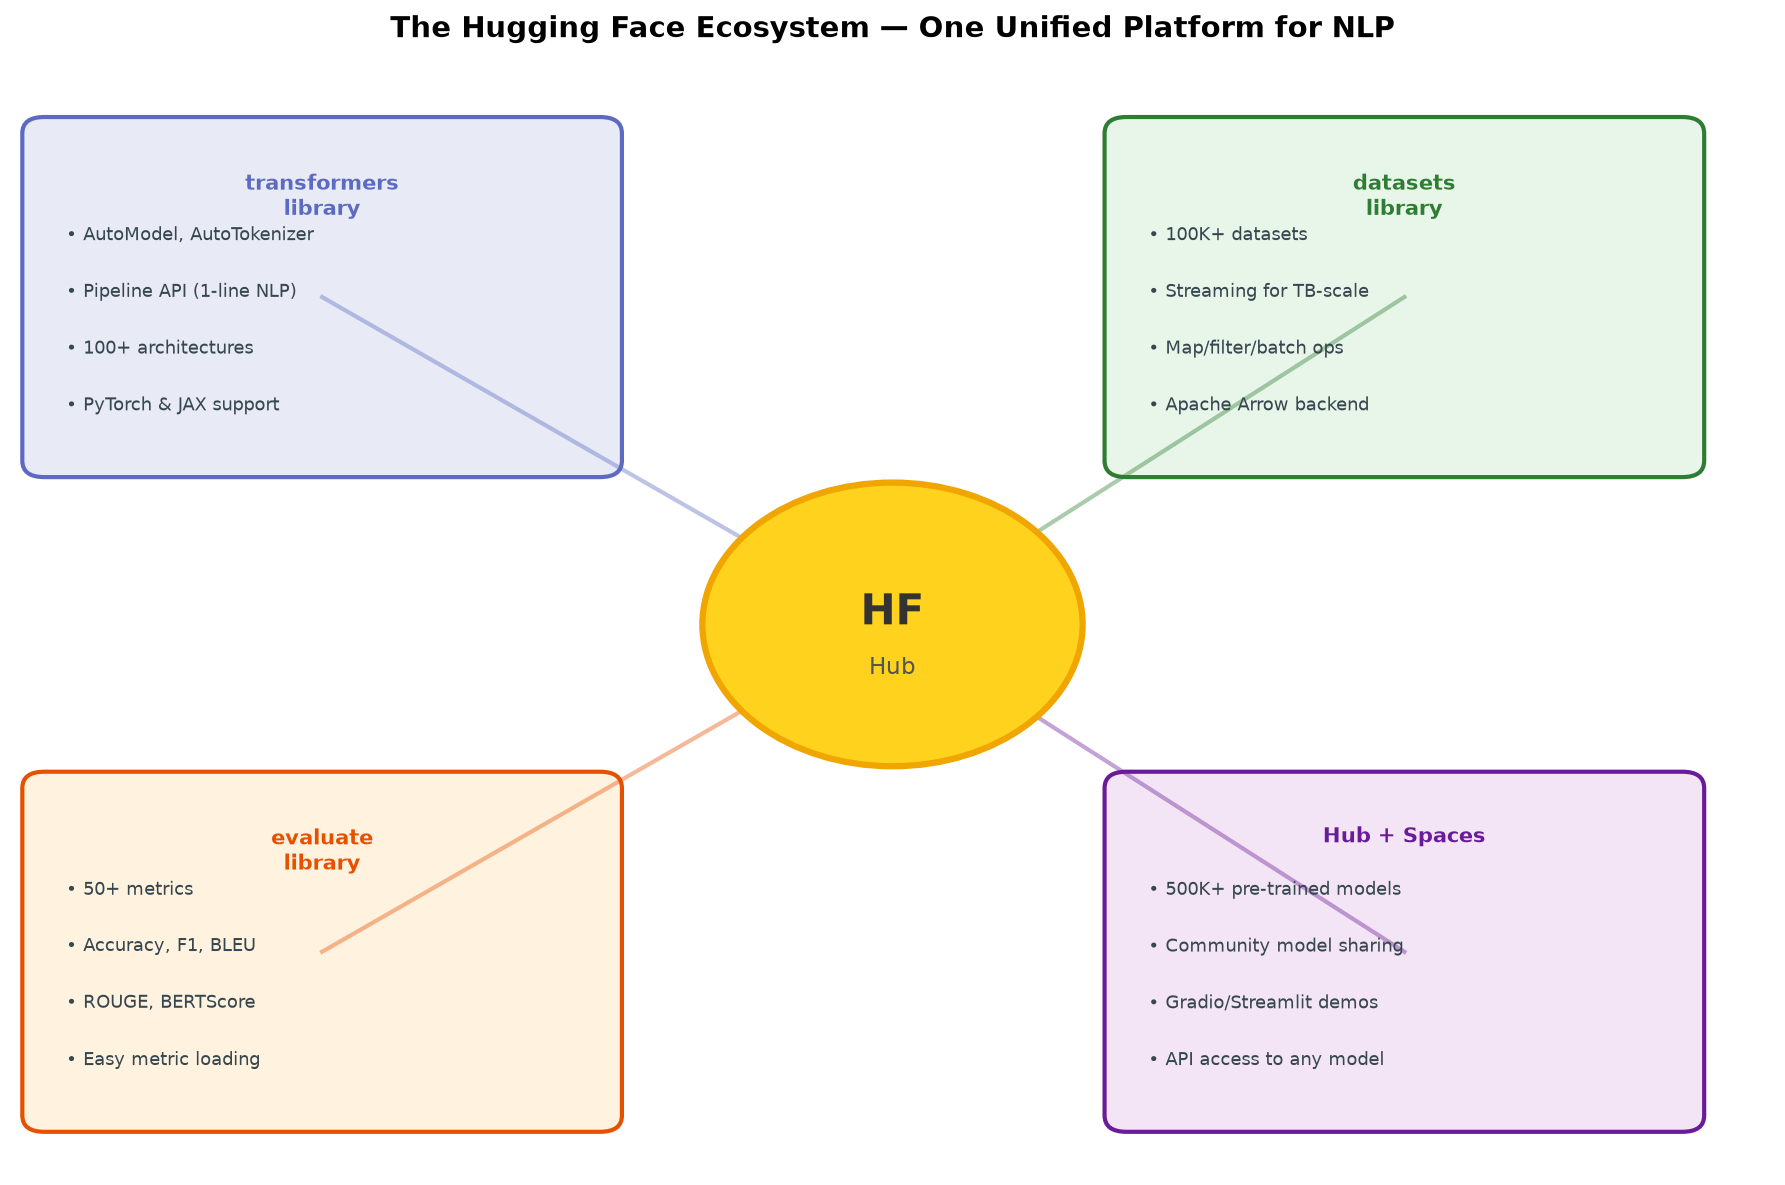

*Figure 1: The Hugging Face Ecosystem — Hub, Transformers, Datasets, and Evaluate*

## 2. The `transformers` Library — Your NLP Swiss Army Knife

The `transformers` library is the backbone of the ecosystem. Three core design patterns:

### 2a. The Auto API — Automatic Model Loading
The `Auto*` classes automatically detect the correct architecture from a model name:
```python
AutoModel.from_pretrained('bert-base-uncased')    # → BERT model
AutoModel.from_pretrained('gpt2')                 # → GPT-2 model
AutoModel.from_pretrained('t5-base')              # → T5 model
```
You don't need to import different classes for different architectures.

### 2b. The Pipeline API — One-Line NLP
Pipelines wrap model + tokenizer + post-processing into a single callable:
```python
pipe = pipeline('sentiment-analysis')
pipe('I love this product!')
# → [{'label': 'POSITIVE', 'score': 0.9998}]
```

---

In [2]:
from transformers import pipeline

# ── 1. Sentiment Analysis ──────────────────────────────────────────────
print('=== 1. Sentiment Analysis ===')
sentiment = pipeline('sentiment-analysis',
                     model='distilbert-base-uncased-finetuned-sst-2-english',
                     device=-1)
reviews = [
    'This product exceeded all my expectations!',
    'Terrible quality, broke after one day.',
    'It was okay, nothing special.',
]
for r in reviews:
    result = sentiment(r)[0]
    print(f'  [{result["label"]:<8} {result["score"]:.3f}] {r}')

=== 1. Sentiment Analysis ===


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

  [POSITIVE 0.999] This product exceeded all my expectations!
  [NEGATIVE 0.999] Terrible quality, broke after one day.
  [NEGATIVE 0.982] It was okay, nothing special.


In [3]:
# ── 2. Named Entity Recognition ───────────────────────────────────────
print('=== 2. Named Entity Recognition ===')
ner = pipeline('ner', model='dbmdz/bert-base-cased-finetuned-conll03-english',
               aggregation_strategy='simple', device=-1)
text = 'Elon Musk founded SpaceX in Hawthorne, California, and Tesla in San Carlos.'
entities = ner(text)
print(f'  Input: "{text}"')
for e in entities:
    print(f'  [{e["entity_group"]:<5}] "{e["word"]}" (score: {e["score"]:.3f})')

=== 2. Named Entity Recognition ===


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: dbmdz/bert-base-cased-finetuned-conll03-english
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Input: "Elon Musk founded SpaceX in Hawthorne, California, and Tesla in San Carlos."
  [LABEL_4] "Elon Musk" (score: 0.941)
  [LABEL_0] "founded" (score: 1.000)
  [LABEL_6] "SpaceX" (score: 0.997)
  [LABEL_0] "in" (score: 1.000)
  [LABEL_8] "Hawthorne" (score: 0.994)
  [LABEL_0] "," (score: 0.996)
  [LABEL_8] "California" (score: 0.999)
  [LABEL_0] ", and" (score: 1.000)
  [LABEL_6] "Tesla" (score: 0.978)
  [LABEL_0] "in" (score: 1.000)
  [LABEL_8] "San Carlos" (score: 0.999)
  [LABEL_0] "." (score: 1.000)


In [4]:
# ── 3. Text Generation ────────────────────────────────────────────────
print('=== 3. Text Generation ===')
generator = pipeline('text-generation', model='./data/gpt2', device=-1)
prompt = 'The future of artificial intelligence in medicine'
result = generator(prompt, max_new_tokens=50, do_sample=True, top_p=0.9,
                   temperature=0.8, pad_token_id=50256)
print(f'  Prompt:    "{prompt}"')
print(f'  Generated: "{result[0]["generated_text"][len(prompt):].strip()[:150]}"')

=== 3. Text Generation ===


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'temperature', 'pad_token_id', 'top_p', 'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


[transformers] Both `max_new_tokens` (=50) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


  Prompt:    "The future of artificial intelligence in medicine"
  Generated: "is clear.

I'm looking forward to talking to you at the upcoming CES in Las Vegas."


In [5]:
# ── 4. Question Answering ─────────────────────────────────────────────
print('=== 4. Extractive Question Answering ===')
from transformers import AutoTokenizer, AutoModelForQuestionAnswering
import torch

qa_tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased-distilled-squad')
qa_model = AutoModelForQuestionAnswering.from_pretrained('distilbert-base-uncased-distilled-squad')
qa_model.eval()

context = """
The Transformer architecture was introduced in 2017 by researchers at Google Brain
in a paper titled 'Attention Is All You Need'. The model relies entirely on 
self-attention mechanisms and eliminates the need for recurrence or convolutions.
BERT, built on the Transformer encoder, was released by Google in 2018 and achieved
state-of-the-art results on 11 NLP benchmarks.
"""
questions = [
    'When was the Transformer architecture introduced?',
    'What paper introduced the Transformer?',
    'How many NLP benchmarks did BERT achieve state-of-the-art on?',
]
for q in questions:
    inputs = qa_tokenizer(q, context, return_tensors='pt')
    with torch.no_grad():
        outputs = qa_model(**inputs)
    start_idx = torch.argmax(outputs.start_logits)
    end_idx = torch.argmax(outputs.end_logits) + 1
    tokens = qa_tokenizer.convert_ids_to_tokens(inputs['input_ids'][0][start_idx:end_idx])
    answer = qa_tokenizer.convert_tokens_to_string(tokens)
    print(f'  Q: {q}')
    print(f'  A: "{answer.strip()}"\n')

=== 4. Extractive Question Answering ===


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

  Q: When was the Transformer architecture introduced?
  A: "2017"

  Q: What paper introduced the Transformer?
  A: "' attention is all you need '"

  Q: How many NLP benchmarks did BERT achieve state-of-the-art on?
  A: "11"



In [6]:
# ── 5. Zero-Shot Classification ───────────────────────────────────────
print('=== 5. Zero-Shot Text Classification ===')
classifier = pipeline('zero-shot-classification',
                      model='typeform/distilbert-base-uncased-mnli', device=-1)
text = 'The central bank raised interest rates for the third consecutive quarter.'
candidate_labels = ['economics', 'sports', 'technology', 'politics', 'entertainment']
result = classifier(text, candidate_labels=candidate_labels)
print(f'  Text: "{text}"')
print(f'  Candidates: {candidate_labels}')
print(f'  Results:')
for label, score in zip(result['labels'], result['scores']):
    bar = '|' * int(score * 30)
    print(f'    {label:<15} {score:.3f} {bar}')

=== 5. Zero-Shot Text Classification ===


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

  Text: "The central bank raised interest rates for the third consecutive quarter."
  Candidates: ['economics', 'sports', 'technology', 'politics', 'entertainment']
  Results:
    economics       0.298 ||||||||
    politics        0.228 ||||||
    technology      0.173 |||||
    entertainment   0.169 |||||
    sports          0.133 |||


## 3. The `datasets` Library — Loading Data in One Line

The `datasets` library provides fast, memory-efficient access to thousands of NLP datasets backed by Apache Arrow (columnar storage).

Key features:
- **One-line loading**: `load_dataset('imdb')` downloads and caches automatically
- **Streaming**: `load_dataset('c4', streaming=True)` handles multi-TB datasets without RAM limits
- **Efficient transforms**: `.map()` applies preprocessing in parallel with Arrow batching
- **Automatic caching**: preprocessed datasets are cached so repeated runs are instant

---

Building synthetic sentiment dataset...
Dataset Structure:
  Train: 4,000 examples
  Test:  1,000 examples


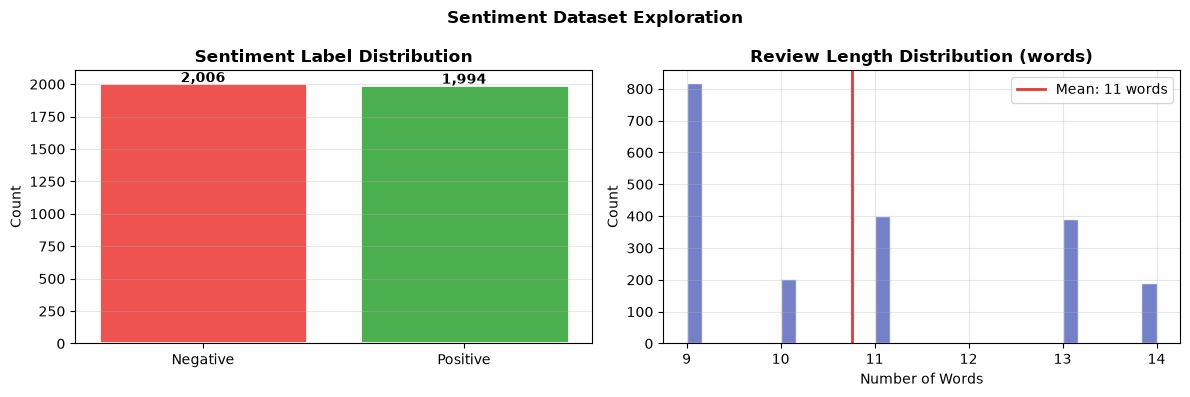

Done.


In [7]:
import matplotlib.pyplot as plt
import numpy as np
from datasets import Dataset
import random

# Synthetic sentiment dataset (avoids network HfUriError in transformers v5)
print('Building synthetic sentiment dataset...')
pos = [
    'This film was absolutely brilliant! The acting was superb and the story compelling.',
    'A masterpiece of modern cinema. I was moved to tears by the end.',
    'Incredible performances throughout. One of the best films of the year.',
    'Deeply moving and beautifully shot. A must-watch for everyone.',
    'Outstanding direction and a riveting script. Loved every moment.',
] * 500
neg = [
    'Dull, predictable, and painfully slow. A complete waste of time.',
    'The acting was wooden and the plot made no sense whatsoever.',
    'One of the worst films I have ever sat through. Avoid at all costs.',
    'Terrible special effects and a nonsensical storyline. Very disappointing.',
    'I fell asleep halfway through. Completely boring and forgettable.',
] * 500
texts = pos + neg
labels = [1]*len(pos) + [0]*len(neg)
pairs = list(zip(texts, labels)); random.seed(42); random.shuffle(pairs)
texts, labels = zip(*pairs)
imdb = {
    'train': Dataset.from_dict({'text': list(texts[:4000]), 'label': list(labels[:4000])}),
    'test':  Dataset.from_dict({'text': list(texts[4000:]), 'label': list(labels[4000:])})
}

print(f'Dataset Structure:')
print(f'  Train: {len(imdb["train"]):,} examples')
print(f'  Test:  {len(imdb["test"]):,} examples')

train_labels = imdb['train']['label']
text_lengths = [len(t.split()) for t in imdb['train']['text'][:2000]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = [train_labels.count(0), train_labels.count(1)]
axes[0].bar(['Negative', 'Positive'], counts, color=['#EF5350', '#4CAF50'], edgecolor='white', lw=2)
axes[0].set_title('Sentiment Label Distribution', fontweight='bold')
for i, c in enumerate(counts):
    axes[0].text(i, c+10, f'{c:,}', ha='center', fontweight='bold')
axes[0].set_ylabel('Count'); axes[0].grid(axis='y', alpha=0.3)
axes[1].hist(text_lengths, bins=30, color='#5C6BC0', edgecolor='white', alpha=0.85)
axes[1].set_title('Review Length Distribution (words)', fontweight='bold')
axes[1].set_xlabel('Number of Words'); axes[1].set_ylabel('Count')
axes[1].axvline(np.mean(text_lengths), color='#E53935', lw=2, label=f'Mean: {np.mean(text_lengths):.0f} words')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle('Sentiment Dataset Exploration', fontweight='bold')
plt.tight_layout()
import os; os.makedirs('outputs', exist_ok=True)
plt.savefig(r'outputs/p8_imdb_exploration.png', dpi=150, bbox_inches='tight')
plt.show()
print('Done.')

## 4. The `Trainer` API — Fine-tuning Without Boilerplate

The `Trainer` API abstracts away the training loop, evaluation, checkpointing, and logging — letting you focus on the model and data.

### Trainer vs. Manual Training Loop

| Feature | Manual Loop | Trainer API |
|---|---|---|
| Gradient accumulation | Write yourself | `gradient_accumulation_steps=4` |
| Mixed precision (FP16) | Write yourself | `fp16=True` |
| Multi-GPU / distributed | Very complex | `device_map='auto'` or DeepSpeed |
| Evaluation per epoch | Write yourself | `eval_strategy='epoch'` |
| Learning rate scheduling | Write yourself | Built-in warmup + linear decay |
| Best model checkpointing | Write yourself | `load_best_model_at_end=True` |
| WandB / TensorBoard logging | Write yourself | `report_to='wandb'` |

The full `TrainingArguments` object controls everything:

```python
TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    warmup_ratio=0.1,              # 10% of steps for LR warmup
    weight_decay=0.01,             # L2 regularization
    eval_strategy='epoch',   # evaluate after each epoch
    save_strategy='best',          # save only the best checkpoint
    load_best_model_at_end=True,   # restore best after training
    fp16=torch.cuda.is_available(),# use half precision on GPU
    report_to='tensorboard',       # logging destination
)
```

---

In [8]:
# Complete Trainer workflow demo using the synthetic imdb dict from above
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer)
import evaluate, numpy as np, torch

# 1. Data (reuse synthetic imdb from previous cell)
train_small = imdb['train'].select(range(500))
val_small   = imdb['test'].select(range(200))

# 2. Tokenizer
model_name = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(model_name)

def preprocess(examples):
    return tokenizer(examples['text'], truncation=True, padding='max_length', max_length=128)

train_tok = train_small.map(preprocess, batched=True)
val_tok   = val_small.map(preprocess, batched=True)
for ds in [train_tok, val_tok]:
    ds.set_format(type='torch', columns=['input_ids','attention_mask','label'])

# 3. Model
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=2,
    id2label={0:'NEGATIVE', 1:'POSITIVE'},
    label2id={'NEGATIVE':0, 'POSITIVE':1}
)

# 4. Metric
accuracy = evaluate.load('accuracy')
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return accuracy.compute(predictions=preds, references=labels)

# 5. Trainer
import os; os.makedirs('outputs/distilbert_imdb', exist_ok=True)
args = TrainingArguments(
    output_dir='outputs/distilbert_imdb',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    learning_rate=3e-5,
    eval_strategy='epoch',
    save_strategy='no',
    report_to='none',
    use_cpu=not torch.cuda.is_available(),
)
trainer = Trainer(
    model=model, args=args,
    train_dataset=train_tok, eval_dataset=val_tok,
    compute_metrics=compute_metrics,
)
print('Fine-tuning DistilBERT on synthetic sentiment data (500 train, 200 val)')
trainer.train()
results = trainer.evaluate()
print(f"Final Accuracy: {results['eval_accuracy']:.4f}")

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fine-tuning DistilBERT on synthetic sentiment data (500 train, 200 val)


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.015989,1.000000
2,No log,0.004215,1.000000
3,No log,0.003408,1.000000


Training Loss,Validation Loss,Epoch,Accuracy
No log,0.003408,3,1.000000


Final Accuracy: 1.0000


## 5. Practical Tips for Working with Pre-trained Models

### Choosing the Right Model Size

| Use Case | Recommended Model | Why |
|---|---|---|
| Quick prototyping | `distilbert-base-uncased` (66M) | 40% faster, 97% of BERT quality |
| Production classification | `bert-base-uncased` (110M) | Reliable, well-understood |
| High accuracy classification | `roberta-large` (355M) | Best in class for understanding |
| Text generation (local) | `gpt2` (117M) | Runs on CPU |
| Text generation (quality) | `gpt2-xl` or `opt-1.3b` | Better quality, needs GPU |
| Instruction following | `google/flan-t5-base` (250M) | Instruction-tuned, free |

### Memory Efficiency Tips

```python
# Load in 8-bit quantization (4x memory reduction)
model = AutoModelForCausalLM.from_pretrained('gpt2', load_in_8bit=True)

# Use half-precision on GPU
model = model.half()  # float16 from float32

# Gradient checkpointing during fine-tuning (trade compute for memory)
model.gradient_checkpointing_enable()

# Use device_map='auto' for automatic multi-GPU distribution
model = AutoModel.from_pretrained('large-model', device_map='auto')
```

---

In [9]:
# Demonstrate model loading from Hub with config inspection
from transformers import AutoConfig, AutoTokenizer

models_to_inspect = [
    'distilbert-base-uncased',
    'bert-base-uncased',
    'roberta-base',
    'gpt2',
]

print('Model Configuration Comparison from Hugging Face Hub:')
print('=' * 72)
print(f'{"Model":<35} {"Arch":<12} {"Layers":<8} {"Hidden":<8} {"Heads"}')
print('-' * 72)
for model_name in models_to_inspect:
    config = AutoConfig.from_pretrained(model_name)
    arch = config.model_type
    layers = getattr(config, 'num_hidden_layers',
              getattr(config, 'n_layer', 'N/A'))
    hidden = getattr(config, 'hidden_size',
              getattr(config, 'n_embd', 'N/A'))
    heads  = getattr(config, 'num_attention_heads',
              getattr(config, 'n_head', 'N/A'))
    print(f'{model_name:<35} {arch:<12} {str(layers):<8} {str(hidden):<8} {heads}')

Model Configuration Comparison from Hugging Face Hub:
Model                               Arch         Layers   Hidden   Heads
------------------------------------------------------------------------


distilbert-base-uncased             distilbert   6        768      12


bert-base-uncased                   bert         12       768      12


roberta-base                        roberta      12       768      12


gpt2                                gpt2         12       768      12
